In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

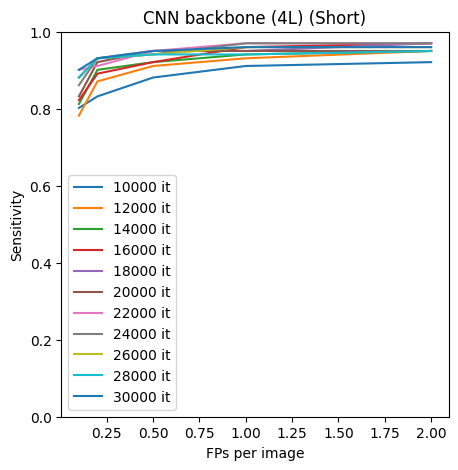

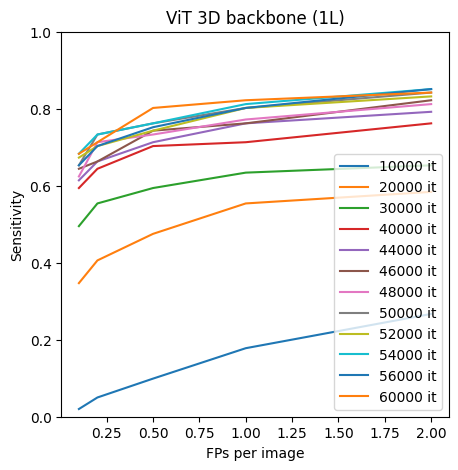

In [5]:
path_results = "../../results"
datasets = ["external"]
models = [
    "decoder_only_s_no_rec_input_edt", "vit3d_1l_decoder_only_no_rec_input_edt"
]
names = ["CNN backbone (4L) (Short)", "ViT 3D backbone (1L)"]
iou = "0.2"
list_fields = []
for dataset in datasets:
    for model in models:
        path_base = Path(path_results) / dataset / model
        # get all subfolders matching pattern
        results = sorted(list(path_base.glob(f"iou{iou}_*")))
        for result in results:
            iterations = result.name.split("_")[-1]
            if iterations == "final":
                continue
            else:
                iterations = int(iterations.replace("k", "")) * 1000
            csv_file = result / "froc.csv"
            df = pd.read_csv(csv_file)
            list_fields.append([dataset, model, iterations, df])




examples_base = [l for l in list_fields if l[0] == "external"]

for i, model in enumerate(models):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    examples = [l for l in examples_base if l[1] == model]
    for example in examples:
        x = [0.1, 0.2, 0.5, 1.0, 2.0]
        y = example[-1].iloc[0, 1:].values[0:5]
        ax.plot(x, y, label=str(example[2]) + " it")
        ax.set_title(names[i])
        ax.set_xlabel("FPs per image")
        ax.set_ylabel("Sensitivity")
        ax.legend()
        ax.set_ylim(0, 1)
    plt.show()

In [7]:
df

NameError: name 'df' is not defined

In [13]:
list(path_base.glob("*"))

[PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_40k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.3_froc_54k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.3_froc_48k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_48k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/inference_50k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/inference_52k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/inference_30k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_60k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.3_froc_final'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_52k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/